In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print(os.getcwd())
print(os.listdir("data"))

c:\Users\LENOVO\Desktop\telco customer shurn
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
import os

print(os.listdir("data"))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [7]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].head())

str
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
print(df["TotalCharges"].isnull().sum())

11


In [14]:
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [17]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


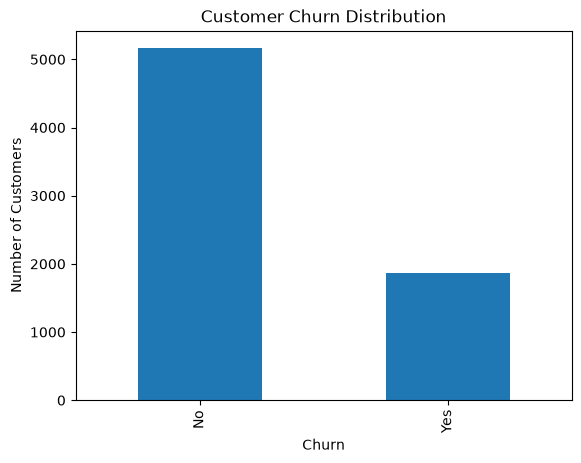

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


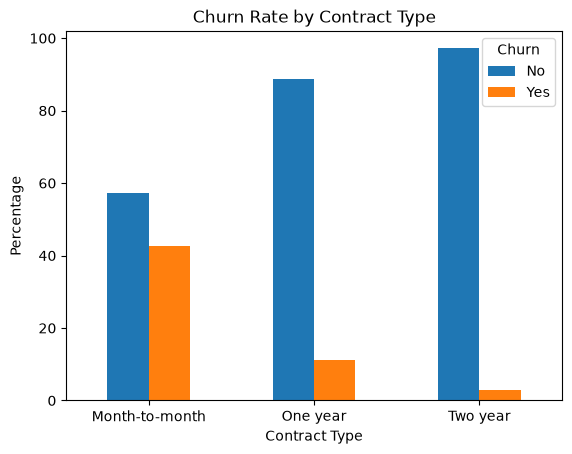

In [20]:
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.show()

In [21]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

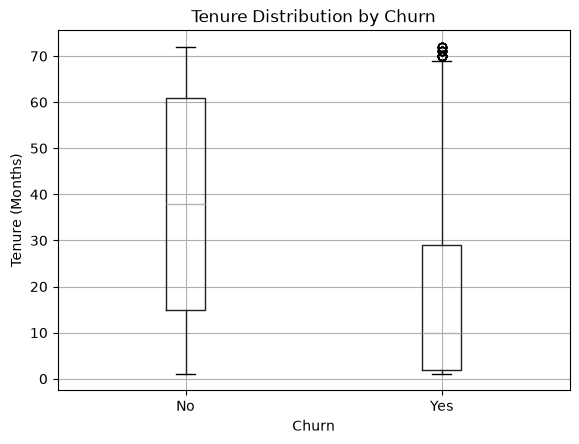

In [22]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [23]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

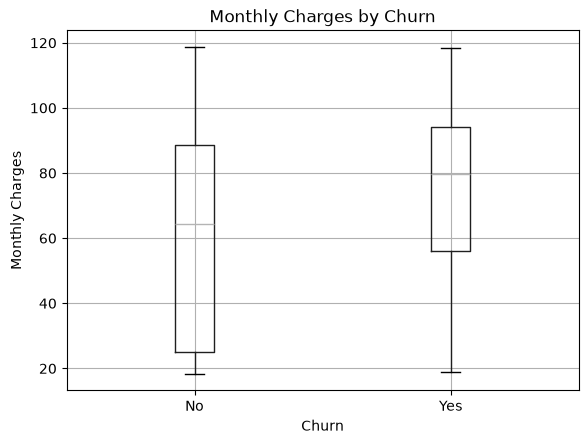

In [24]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [25]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


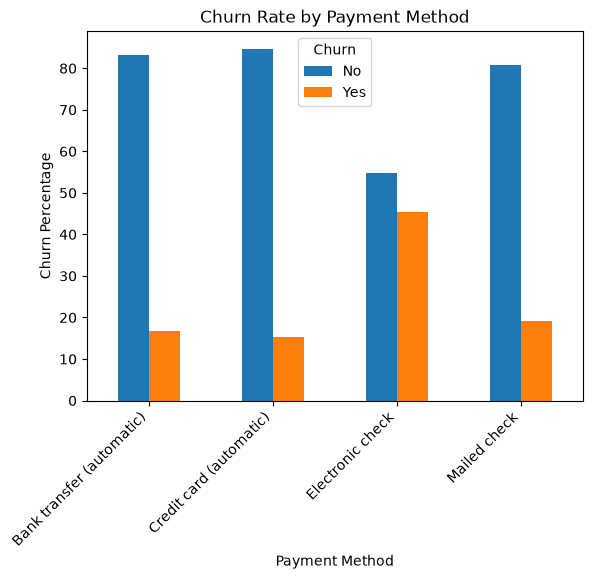

In [26]:
payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage")

plt.xticks(rotation=45, ha="right")
plt.show()

In [27]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


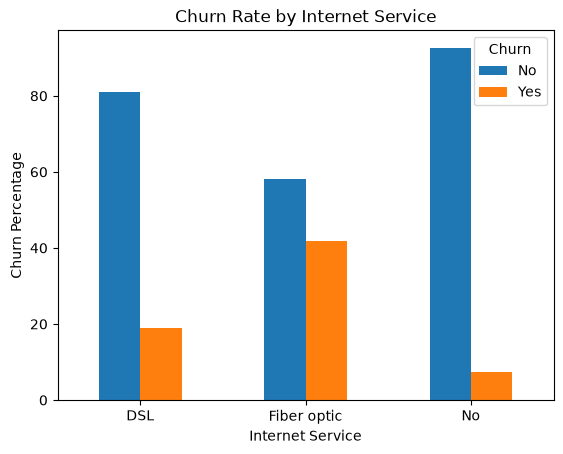

In [28]:
internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")

plt.xticks(rotation=0)
plt.show()

In [30]:
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (7032, 19)
Target: (7032,)


In [31]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (7032, 30)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5625
Testing records: 1407


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [34]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [35]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


In [36]:
churn_probability = model.predict_proba(X_test_scaled)[:, 1]

print("Churn probabilities:")
print(churn_probability[:10])

Churn probabilities:
[0.01711495 0.59613179 0.00476432 0.20004408 0.10022205 0.4700293
 0.02661132 0.16414898 0.68614136 0.01518016]


In [37]:
customer_prediction = np.where(
    churn_probability >= 0.5,
    "Likely to churn",
    "Likely to stay"
)

print(customer_prediction[:10])

['Likely to stay' 'Likely to churn' 'Likely to stay' 'Likely to stay'
 'Likely to stay' 'Likely to stay' 'Likely to stay' 'Likely to stay'
 'Likely to churn' 'Likely to stay']


In [38]:
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (7032, 19)
Target: (7032,)


In [44]:
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (7032, 30)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5625
Testing records: 1407


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [47]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")



Model training completed successfully!


In [48]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


In [49]:
churn_probability = model.predict_proba(X_test_scaled)[:, 1]

print("Churn probabilities:")
print(churn_probability[:10])

Churn probabilities:
[0.01711495 0.59613179 0.00476432 0.20004408 0.10022205 0.4700293
 0.02661132 0.16414898 0.68614136 0.01518016]


In [50]:
customer_prediction = np.where(
    churn_probability >= 0.5,
    "Likely to churn",
    "Likely to stay"
)

print(customer_prediction[:10])

['Likely to stay' 'Likely to churn' 'Likely to stay' 'Likely to stay'
 'Likely to stay' 'Likely to stay' 'Likely to stay' 'Likely to stay'
 'Likely to churn' 'Likely to stay']


In [51]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 80.38 %


In [52]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision * 100, 2), "%")

Precision: 64.76 %


In [53]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall * 100, 2), "%")

Recall: 57.49 %


In [54]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, churn_probability)

print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(auc, 3))

F1 Score: 0.609
ROC-AUC: 0.836


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [159 215]]


In [57]:
TN, FP, FN, TP = cm.ravel()

print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives:", TP)

True Negatives: 916
False Positives: 117
False Negatives: 159
True Positives: 215


In [58]:
print("Churn customers correctly identified:", TP)
print("Non-churn customers misclassified:", FP)
print("Actual churn customers missed:", FN)

Churn customers correctly identified: 215
Non-churn customers misclassified: 117
Actual churn customers missed: 159


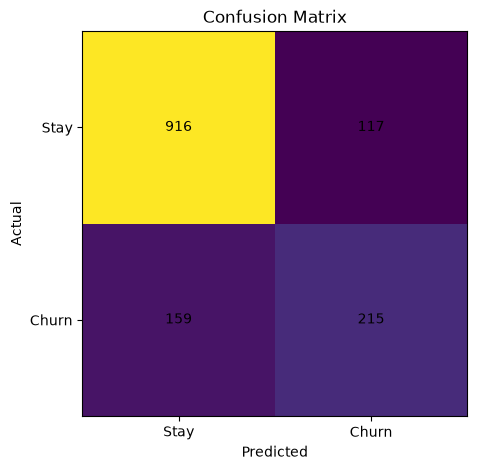

In [59]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Stay", "Churn"])
plt.yticks([0, 1], ["Stay", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [60]:
new_customer = X_test.iloc[[0]]

new_customer_scaled = scaler.transform(new_customer)

probability = model.predict_proba(new_customer_scaled)[0][1]

if probability >= 0.5:
    prediction = "Likely to churn"
else:
    prediction = "Likely to stay"

print("Churn Probability:", round(probability * 100, 2), "%")
print("Prediction:", prediction)

Churn Probability: 1.71 %
Prediction: Likely to stay


In [61]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Churn Probability": churn_probability,
    "Prediction": customer_prediction
})

results["Actual"] = results["Actual"].map({
    0: "Stayed",
    1: "Churned"
})

results.head(10)

,Actual,Churn Probability,Prediction
0,Stayed,0.017115,Likely to stay
1,Stayed,0.596132,Likely to churn
2,Stayed,0.004764,Likely to stay
3,Churned,0.200044,Likely to stay
4,Stayed,0.100222,Likely to stay
5,Churned,0.470029,Likely to stay
6,Stayed,0.026611,Likely to stay
7,Stayed,0.164149,Likely to stay
8,Churned,0.686141,Likely to churn
9,Stayed,0.015180,Likely to stay


In [62]:
high_risk_customers = results[
    results["Churn Probability"] >= 0.7
]

print("High-risk customers:", len(high_risk_customers))

high_risk_customers.head(10)

High-risk customers: 83


,Actual,Churn Probability,Prediction
10,Stayed,0.705919,Likely to churn
15,Churned,0.774921,Likely to churn
59,Churned,0.721799,Likely to churn
91,Churned,0.706572,Likely to churn
115,Churned,0.780708,Likely to churn
126,Churned,0.770695,Likely to churn
137,Stayed,0.734656,Likely to churn
194,Churned,0.733823,Likely to churn
211,Stayed,0.846212,Likely to churn
214,Churned,0.700423,Likely to churn


## Business Interpretation

The model helps the telecom company identify customers who are likely to churn.

Customers with a high predicted churn probability can be targeted with proactive retention strategies such as discounts, improved service plans, personalized offers, or customer support.

False Positives occur when loyal customers are incorrectly identified as likely to churn. This may cause the company to provide unnecessary retention offers.

False Negatives occur when customers who are actually going to churn are predicted to stay. This can be more costly because the company may lose the customer's future revenue.

Therefore, reducing False Negatives and improving Recall for the churn class is particularly important for this business problem.

## Business Interpretation

The model helps the telecom company identify customers who are likely to churn.

Customers with a high predicted churn probability can be targeted with proactive retention strategies such as discounts, improved service plans, personalized offers, or customer support.

False Positives occur when loyal customers are incorrectly identified as likely to churn. This may cause the company to provide unnecessary retention offers.

False Negatives occur when customers who are actually going to churn are predicted to stay. This can be more costly because the company may lose the customer's future revenue.

Therefore, reducing False Negatives and improving Recall for the churn class is particularly important for this business problem.

## Suggested Improvement

One improvement is to adjust the classification threshold.

Instead of always using 50% as the cutoff, the company can choose a threshold based on the cost of losing a customer versus the cost of providing a retention offer.

A lower threshold can identify more potential churn customers and improve recall, although it may increase the number of false positives.

## Conclusion

A Logistic Regression model was developed to predict customer churn.

The model uses customer attributes such as tenure, monthly charges, total charges, contract type, payment method, internet service, and other service-related features.

The model provides a probability of churn and classifies customers into "Likely to churn" and "Likely to stay".

Model performance was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and a Confusion Matrix.

From a business perspective, identifying customers who are likely to churn can help the telecom company take proactive retention actions and reduce customer loss.

The model can be further improved by adjusting the classification threshold and tuning the model based on the company's retention costs.

In [65]:
results.to_csv("churn_predictions.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!
